# INTERPOLATE ERA5, COMPUTE VSD

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

_______
# Data

In [2]:
drifters_sources = 'all_med_variational_10min_v0.nc'
#drifters_sources = '10days_all_med_variational_10min_v0.nc'
df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_55102/3776149156.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))


In [3]:
files = glob('/Users/mdemol/DATA_WIND/era5/*')

In [4]:
files

['/Users/mdemol/DATA_WIND/era5/2023_waves_interp.nc',
 '/Users/mdemol/DATA_WIND/era5/era5_agesc_rio_z0.nc',
 '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726002205.1540956-13738-7-c8d88fd1-3ec7-4113-8790-c92c59938aa6.nc',
 '/Users/mdemol/DATA_WIND/era5/2023_waves.nc',
 '/Users/mdemol/DATA_WIND/era5/corrected_coords_d68_interp.nc',
 '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726052574.6907787-10906-10-da2d6902-362a-4e2a-9333-df9d5a844d68.nc',
 '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1725888040.2442634-4062-7-717f5d1f-4dbc-4297-ba65-42766024d861.nc',
 '/Users/mdemol/DATA_WIND/era5/era5_agesc_rio_z15.nc']

# CORECT WRONG COORDS
era = xr.open_dataset('/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726052574.6907787-10906-10-da2d6902-362a-4e2a-9333-df9d5a844d68.nc').sortby('latitude')
erac = xr.open_dataset('/Users/mdemol/DATA_WIND/era5/2023_waves.nc').sel(longitude050 = slice(0,15), latitude050 = slice(36, 45)).rename({'latitude050' :'latitude', 'longitude050' :'longitude'})
era['longitude'] = era['longitude']*2
era['latitude'] = (era['latitude']-40)*2+36
era = era.sel(longitude = slice(0,15), latitude = slice(36, 45))
erac = erac.sel(time = era.time)

era.to_netcdf('corrected_coords_d68.nc')
(era.mwd.isel(time=4)-erac.mwd.isel(time=4)).plot()

In [5]:
#era5 = ['/Users/mdemol/DATA_WIND/era5/2023_waves_interp.nc',
#        '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1726002205.1540956-13738-7-c8d88fd1-3ec7-4113-8790-c92c59938aa6.nc',#u10 etc
#        '/Users/mdemol/DATA_WIND/era5/adaptor.mars.internal-1725888040.2442634-4062-7-717f5d1f-4dbc-4297-ba65-42766024d861.nc', # lon, lat wrong coords
#        #'/Users/mdemol/DATA_WIND/era5/corrected_coords_d68.nc',# corrected coords
#        '/Users/mdemol/DATA_WIND/era5/corrected_coords_d68_interp.nc',#ust, vst etc
#        #'/Users/mdemol/DATA_WIND/era5/era5_agesc_rio_z15.nc', 
#        #'/Users/mdemol/DATA_WIND/era5/era5_agesc_rio_z0.nc', #vsd from Rio (old+updated), AGESC
#       ]
#era = xr.open_mfdataset(era5, compat='override')


In [6]:
era515 = xr.open_dataset('/Users/mdemol/DATA_WIND/era5/era5_agesc_rio_z15.nc').compute()
era50 = xr.open_dataset('/Users/mdemol/DATA_WIND/era5/era5_agesc_rio_z0.nc').compute()


In [7]:
era5 = xr.merge([era50, era515])

In [8]:
era5

<xarray.Dataset> Size: 6GB
Dimensions:            (longitude: 61, latitude: 33, time: 3672)
Coordinates:
  * longitude          (longitude) float32 244B 0.0 0.25 0.5 ... 14.5 14.75 15.0
  * latitude           (latitude) float32 132B 44.0 43.75 43.5 ... 36.25 36.0
  * time               (time) datetime64[ns] 29kB 2023-03-01 ... 2023-07-31T2...
Data variables: (12/96)
    u10                (time, latitude, longitude) float64 59MB 1.498 ... 3.376
    v10                (time, latitude, longitude) float64 59MB -1.426 ... -4...
    t2m                (time, latitude, longitude) float64 59MB 275.2 ... 301.5
    ewss               (time, latitude, longitude) float64 59MB 189.8 ... 153.2
    iews               (time, latitude, longitude) float64 59MB 0.03162 ... 0...
    inss               (time, latitude, longitude) float64 59MB -0.03147 ... ...
    ...                 ...
    Us_agesc_z15       (latitude, time, longitude) float64 59MB nan ... 1.066...
    Ues_agesc_z15      (time, latitude, longitude) float64 59MB nan ... 0.0176
    Ue_rio_z15         (latitude, time, longitude) float64 59MB 0.01561 ... 0...
    Ue_rioold_z15      (latitude, time, longitude) float64 59MB 0.006691 ... ...
    Ua_agesc_z15       (time, latitude, longitude) float64 59MB nan ... 0.02234
    Uw_agesc_z15       (time, latitude, longitude) float64 59MB nan ... 0.01761
Attributes:
    Conventions:  CF-1.6
    history:      2024-09-10 21:05:21 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

__________
# era5 + RIO MODEL

In [9]:
lon = df.longitude.values
lat = df.latitude.values
t = pd.to_datetime(df.datetime).values
ds0 = era5.interp(longitude=('z', lon), latitude=('z',lat), time= ('z',t))
df0 = ds0.to_dataframe()
df0.index.names = ['row_number']
#df0['f'] = 2 * 2 * np.pi / 86164.1 * np.sin(df0.latitude * np.pi / 180)
#df0 = df0.rename(columns = {'ewss':'taue', 'nsss':'taun'})
# Integrated stress -> mean stress
#int_time = 1*3600
#df0['taue'] = df0['iews']
#df0['taun'] = df0['inss']
#cst_rio_z0(df0)
#cst_rio_z15(df0)
#agescmed(df0, 0)
#agescmed(df0, 15)
#agescmed(df0, 50)
df0.to_csv(os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv'))

In [ ]:
def cst_rio_z0(df):
    
    #theta0 = - 22.5 * np.pi / 180 * np.sign(df.f)
    #beta0 = 0.6
    theta0 = - 33.125 * np.pi / 180 * np.sign(df.f)
    beta0 = 1.08
    
    uek_e = beta0 * (np.cos(theta0) * df.taue - np.sin(theta0) * df.taun)
    uek_n = beta0 * (np.sin(theta0) * df.taue + np.cos(theta0) * df.taun)
    df['wde0_rio'] = df.f * uek_n
    df['wdn0_rio'] = -df.f * uek_e

def cst_rio_z15(df):
    
    #theta15 = - 37.5 * np.pi / 180 * np.sign(df.f)#adapted for mediterranean sea
    #beta15 = 0.15

    theta15 = - 62.5 * np.pi / 180 * np.sign(df.f)#adapted for mediterranean sea
    beta15 = 0.35
    
    uek_e = beta15 * (np.cos(theta15) * df.taue - np.sin(theta15) * df.taun)
    uek_n = beta15 * (np.sin(theta15) * df.taue + np.cos(theta15) * df.taun)
    df['wde15_rio'] = df.f * uek_n
    df['wdn15_rio'] = -df.f * uek_e

def agescmed(df, z):
    # cstes
    rhow = 1.03*1e4 
    rhoa = 1.2
    g = 9.81

    #vars
    U10 = df.u10 + 1j*df.v10
    u10 = np.conj(U10)*U10
    Us0 = df.ust + 1j *df.vst
    dxS = (df.lgws + 1j *df.mgws)/3600 #accumulated on one hour
    omega = 2*np.pi/df.mwp
    k = omega**2/g
    K = k*np.exp(1j*df.mwd*np.pi/180)
    
    Cd = (2.7/u10 + 0.142 +0.076*u10)/1e3 # neutral drag coeff
    Az = 1.2*1e-4 * U10**2 # vertical velocity profile considered uniform in the whole bassin m2.s-1
    #tau = rhoa * Cd * u10 * U10 # wind stress if not in the dataset
    tau = df.taue + 1j *df.taun
    m=(1+1j)*np.sqrt(df.f/(2*Az))
    
    Ue = tau/(rhow*Az*m)*np.exp(m*z)
    Utaus = dxS/(rhow*Az*m)*np.exp(m*z)
    if z==0: Us = Us0 #work well
    else : Us = m**2*Us0/(4*k**2-m**2)*np.exp(2*k*z)#PB
    Ues = -2*k*m*Us0/(4*k**2-m**2)*np.exp(m*z)

    U_ek = Ue + Utaus + Us + Ues
    df[f'uek{z}_agesc'] = np.real(U_ek)
    df[f'vek{z}_agesc'] = np.imag(U_ek)
    df[f'wde{z}_agesc'] = df.f * np.imag(U_ek)
    df[f'wdn{z}_agesc'] = -df.f * np.real(U_ek)

____________
# Some plots

In [ ]:
df0 = pd.read_csv(os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv'))
df0.columns

In [37]:
df0.wde15_r

0        -3.642340e-06
1        -3.531180e-06
2        -3.377912e-06
3        -3.224727e-06
4        -3.071636e-06
              ...     
404300    1.699878e-07
404301    1.716771e-07
404302    1.734787e-07
404303    1.754046e-07
404304    1.774660e-07
Name: wde15_rio, Length: 404305, dtype: float64

In [47]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    #da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with 

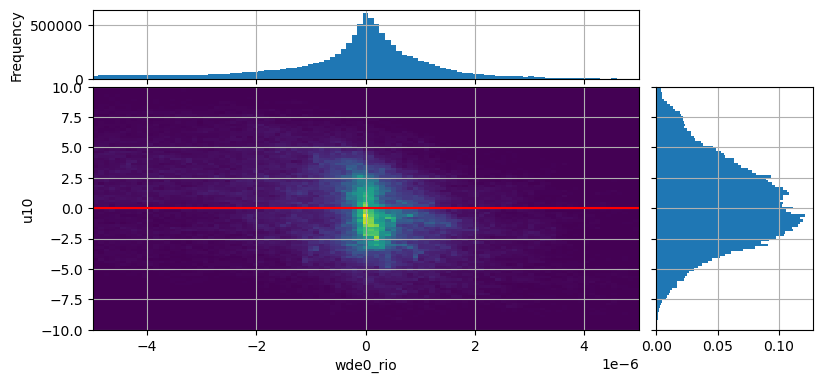

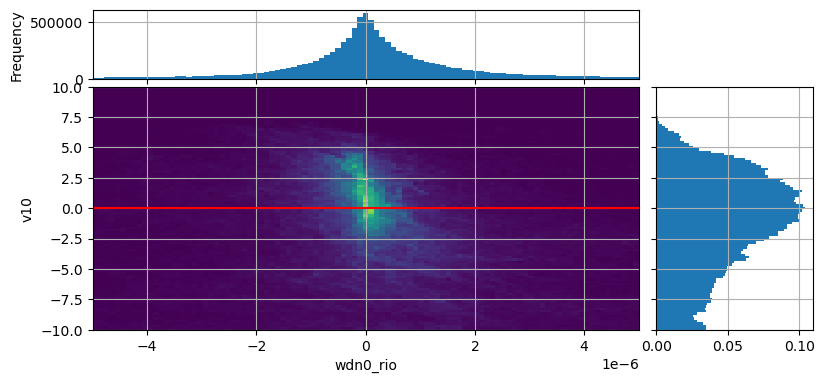

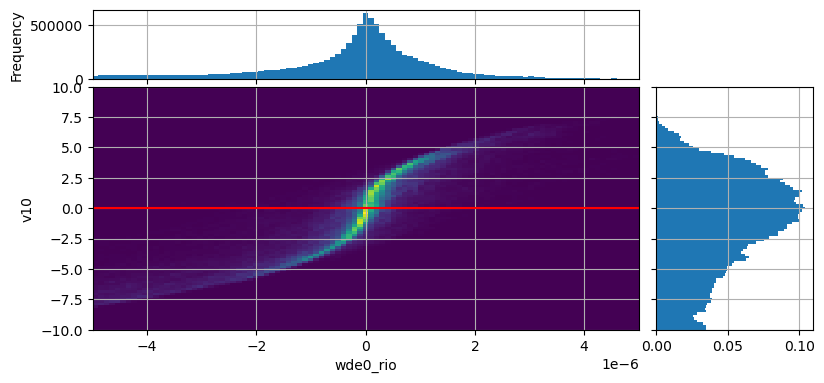

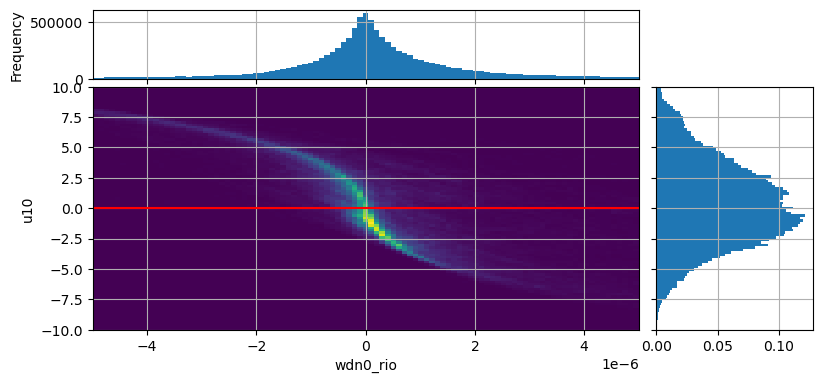

In [48]:
binx = np.linspace(-5e-6, 5e-6, 100)
biny = np.linspace(-10, 10, 100)

plot_join_pdfs(ds=df0, x='wde0_rio',y='u10',  binx=binx, biny=biny)
plot_join_pdfs(ds=df0, x='wdn0_rio',y='v10',  binx=binx, biny=biny)

plot_join_pdfs(ds=df0, x='wde0_rio',y='v10',  binx=binx, biny=biny)
plot_join_pdfs(ds=df0, x='wdn0_rio',y='u10',  binx=binx, biny=biny)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_24465/3574581952.py:52: UserWarning: This figure includes Axes that are not compatible with 

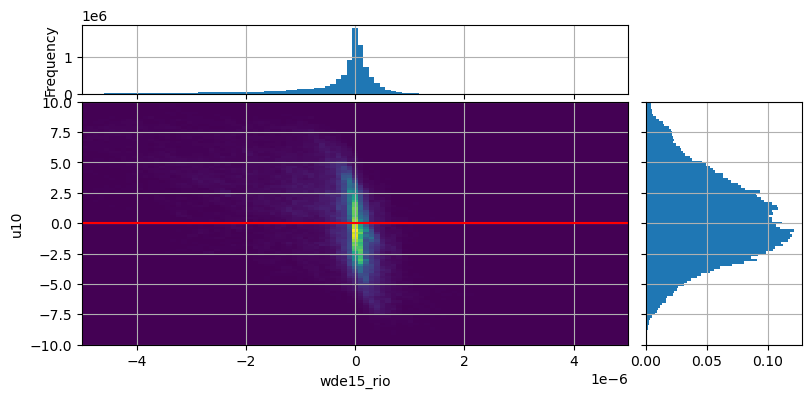

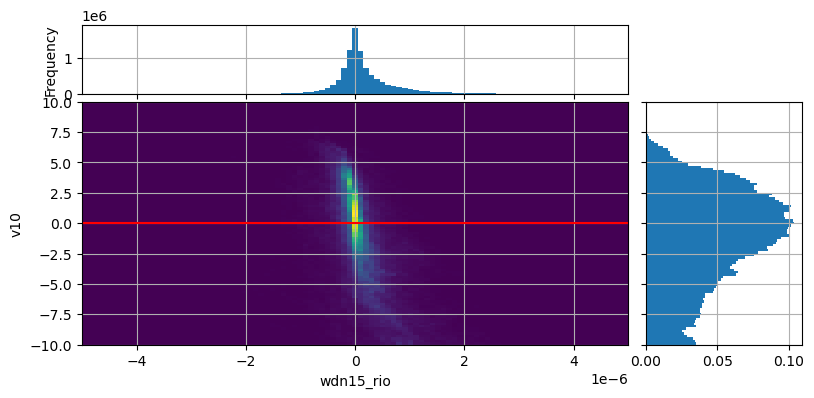

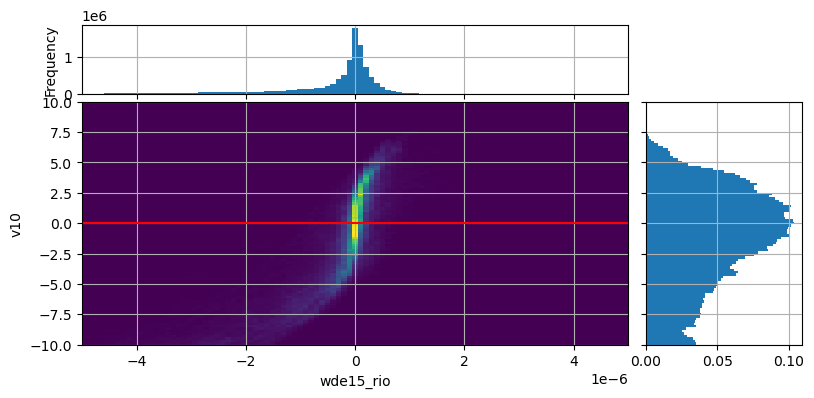

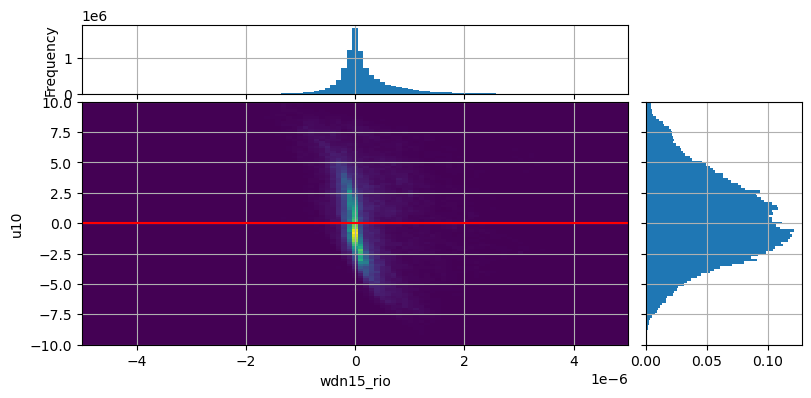

In [49]:
binx = np.linspace(-5e-6, 5e-6, 100)
biny = np.linspace(-10, 10, 100)

plot_join_pdfs(ds=df0, x='wde15_rio',y='u10',  binx=binx, biny=biny)
plot_join_pdfs(ds=df0, x='wdn15_rio',y='v10',  binx=binx, biny=biny)

plot_join_pdfs(ds=df0, x='wde15_rio',y='v10',  binx=binx, biny=biny)
plot_join_pdfs(ds=df0, x='wdn15_rio',y='u10',  binx=binx, biny=biny)

In [13]:
#df0.to_csv(os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv'))

In [18]:
df0.wdn15.mean(), df0.wdn15.std()

(1.7849408319287998e-07, 6.490975129960646e-07)

In [19]:
abs(df0.wdn15).median()

1.959757111892836e-07

In [20]:
abs(df0.wde15).median()

2.2934632107256488e-07